In [81]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import resample

In [82]:
patients_train = [
    '101', '102', '104', '105', '106', '107', '108', '109', '112', '113', 
    '114', '115', '116', '117', '118', '121', '122', '123', '200', '201', 
    '202', '205', '207', '208', '209', '210', '212', '213', '214', '215', 
    '219', '220', '221', '223', '228', '230', '231', '232', '234'
]

# 10 Pacientes para TEST (Tu set de validación clínica independiente)
patients_test = [
    '100', '103', '111', '119', '124', '203', '217', '222', '233'
]

In [83]:
db_dir = "../data/mitdb_data"

def beats_extraction_hybrid(patient_list, dir_path=db_dir, window_size=1500):
    X_signals = []
    X_rr_features = []
    y_labels = []
    
    # Mapeo AAMI estándar (0=N, 1=S, 2=V, 3=F, 4=Q)
    aami_mapping = {'N':0, 'L':0, 'R':0, 'e':0, 'j':0, 
                    'A':1, 'a':1, 'J':1, 'S':1, 
                    'V':2, 'E':2, 'F':3, '/':4, 'f':4, 'Q':4}
    
    fs_target = 500  # Escalamos a 500 Hz para mantener compatibilidad con QTDB
    half_w = window_size // 2

    for patient in patient_list:
        record_path = os.path.join(dir_path, patient)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        # 1. Remuestrear la señal completa a 500 Hz
        num_samples = int(len(record.p_signal) * fs_target / record.fs)
        signals_resampled = resample(record.p_signal, num_samples)
        
        # 2. Escalar los índices de los picos a la nueva frecuencia de 500 Hz
        resample_factor = fs_target / record.fs
        peaks_resampled = np.array([int(p * resample_factor) for p in annotation.sample])
        symbols = annotation.symbol
        
        # 3. Calcular los intervalos RR basados en los picos ya escalados (en muestras de 500Hz)
        rr_intervals = np.diff(peaks_resampled)
        
        # Recorremos los latidos (evitando el primero y el último para tener RR previo y siguiente)
        for i in range(1, len(peaks_resampled) - 1):
            sym = symbols[i]
            if sym not in aami_mapping:
                continue
                
            idx = peaks_resampled[i]
            
            # Validar que la ventana ampliada de 1500 no se salga de la señal remuestreada
            if idx - half_w < 0 or idx + half_w > len(signals_resampled):
                continue
                
            # Extraer Rama 1: Señal de la ventana ampliada (1500, 2)
            beat_signal = signals_resampled[idx - half_w : idx + half_w, :]
            
            # Extraer Rama 2: Características de Ritmo (RR)
            rr_previo = rr_intervals[i-1]
            rr_siguiente = rr_intervals[i]
            
            # Media local de los últimos 8 intervalos RR para conocer el ritmo base del paciente
            start_history = max(0, i-8)
            rr_local_mean = np.mean(rr_intervals[start_history:i])
            
            # Métrica de relación (ratio) local
            rr_ratio = rr_previo / (rr_local_mean + 1e-8)
            
            # Guardamos los datos en las listas correspondientes
            X_signals.append(beat_signal)
            X_rr_features.append([rr_previo, rr_siguiente, rr_local_mean, rr_ratio])
            y_labels.append(aami_mapping[sym])
            
    return np.array(X_signals), np.array(X_rr_features), np.array(y_labels)

data_folder = "../data"
npy_dir = os.path.join(data_folder, "npy_data_mitbih")

if not os.path.exists(npy_dir) or len(os.listdir(npy_dir)) == 0:
    print("Creating hybrid npy data...")
    if not os.path.exists(npy_dir): os.makedirs(npy_dir)
        
    # Extraemos el set híbrido completo
    X_train_sig, X_train_rr, y_train = beats_extraction_hybrid(patients_train)
    X_test_sig, X_test_rr, y_test   = beats_extraction_hybrid(patients_test)
    
    # Guardamos los 3 componentes para Train y Test
    np.save(os.path.join(npy_dir, "X_train_sig.npy"), X_train_sig)
    np.save(os.path.join(npy_dir, "X_train_rr.npy"), X_train_rr)
    np.save(os.path.join(npy_dir, "y_train_mitbih.npy"), y_train)
    
    np.save(os.path.join(npy_dir, "X_test_sig.npy"), X_test_sig)
    np.save(os.path.join(npy_dir, "X_test_rr.npy"), X_test_rr)
    np.save(os.path.join(npy_dir, "y_test_mitbih.npy"), y_test)
    print("Hybrid data saved.")
else:
    print("Loading hybrid data from disk...")
    X_train_sig = np.load(os.path.join(npy_dir, "X_train_sig.npy"))
    X_train_rr  = np.load(os.path.join(npy_dir, "X_train_rr.npy"))
    y_train     = np.load(os.path.join(npy_dir, "y_train_mitbih.npy"))
    
    X_test_sig  = np.load(os.path.join(npy_dir, "X_test_sig.npy"))
    X_test_rr   = np.load(os.path.join(npy_dir, "X_test_rr.npy"))
    y_test      = np.load(os.path.join(npy_dir, "y_test_mitbih.npy"))

Loading hybrid data from disk...


In [84]:
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std

X_train_sig_norm, _, _ = normalize(X_train_sig)
X_test_sig_norm, _, _ = normalize(X_test_sig)

In [95]:
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.utils import to_categorical

n_samples, timesteps, channels = X_train_sig_norm.shape
X_flat = X_train_sig_norm.reshape(n_samples, timesteps * channels)

rus = RandomUnderSampler(sampling_strategy= {0: 40000})

X_res, y_res = rus.fit_resample(X_flat, y_train)

X_train_rus = X_res.reshape(-1, timesteps, channels)

In [96]:
# %% [Mapeo y Normalización de la rama RR]
from sklearn.preprocessing import StandardScaler

# 1. Recuperamos los índices de las muestras seleccionadas por el RUS 
# para recortar X_train_rr a la par que las señales
indices_guardados = rus.sample_indices_
X_train_rr_rus = X_train_rr[indices_guardados]

# 2. Escalamos los intervalos numéricos con StandardScaler
scaler = StandardScaler()
X_train_rr_norm = scaler.fit_transform(X_train_rr_rus)
X_test_rr_norm = scaler.transform(X_test_rr) # El test no lleva RUS, se escala directo

Vamos a modificar y_train_rus de tal forma que lo dejamos de forma binaria

In [97]:
abnormal_classes = [1, 2, 3, 4]

y_train_binary_raw = np.isin(y_res, abnormal_classes).astype(int)
y_test_binary_raw = np.isin(y_test, abnormal_classes).astype(int)

y_train_binary = to_categorical(y_train_binary_raw, num_classes=2)
y_test_binary = to_categorical(y_test_binary_raw, num_classes=2)

print("Distribución binaria real en TRAIN (0=N, 1=Arritmias):")
print(f"  Clase 0 (N): {(y_train_binary_raw == 0).sum()}") 
print(f"  Clase 1 (Anómalas): {(y_train_binary_raw == 1).sum()}")

Distribución binaria real en TRAIN (0=N, 1=Arritmias):
  Clase 0 (N): 40000
  Clase 1 (Anómalas): 14807


# Etiquetador binario
Ya tenemos nuestro set de etiquetas binario. Así que ya podemos entrenar nuestro modelo.

In [98]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D,
                                     Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout,
                                     SpatialDropout1D, GlobalAveragePooling1D, Reshape, multiply, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [99]:
def build_multimodal_network(window_size=1500, num_channels=2, rr_features_dim=4):
    signal_input = Input(shape=(1500, 2), name="signal_input")

    conv_low = Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(signal_input)
    conv_mid = Conv1D(filters=16, kernel_size=15, padding="same", activation="relu")(signal_input)
    conv_high = Conv1D(filters=16, kernel_size=40, padding="same", activation="relu")(signal_input)
    conv_layer = concatenate([conv_low, conv_mid, conv_high])

    se_squeeze = GlobalAveragePooling1D()(conv_layer)
    se_ex1  = Dense(12, activation='relu', use_bias=False)(se_squeeze)
    se_ex2  = Dense(48, activation='sigmoid', use_bias=False)(se_ex1)
    se_scale = Reshape((1, 48))(se_ex2)
    conv_attended = multiply([conv_layer, se_scale])
    norm_1 = BatchNormalization()(conv_attended)

    lstm_1 = Bidirectional(LSTM(64, return_sequences=True))(norm_1)
    dropout_1 = SpatialDropout1D(0.3)(lstm_1)

    lstm_2 = Bidirectional(LSTM(32, return_sequences=True))(dropout_1)
    dropout_2 = SpatialDropout1D(0.3)(lstm_2)

    avg_pool = GlobalAveragePooling1D()(dropout_2)
    max_pool = GlobalMaxPooling1D()(dropout_2)
    signal_features = concatenate([avg_pool, max_pool])

    rr_input = Input(shape=(4,), name="rr_input")
    rr_dense = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(rr_input)
    rr_features = BatchNormalization()(rr_dense)
    rr_combined = concatenate([signal_features, rr_features])

    dense_1 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(rr_combined)
    dropout_3 = Dropout(0.4)(dense_1)
    dense_2 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(dropout_3)
    output_layer = Dense(2, activation='softmax')(dense_2)

    return Model(inputs=[signal_input, rr_input], outputs=output_layer)

model = build_multimodal_network()
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ signal_input        │ (None, 1500, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 1500, 16)  │        176 │ signal_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 1500, 16)  │        496 │ signal_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 1500, 16)  │      1,296 │ signal_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_31      │ (None, 1500, 48)  │          0 │ conv1d_36[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_37[0][0],  │
│                     │                   │            │ conv1d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ concatenate_31[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 12)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 48)        │        576 │ dense_62[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 1, 48)     │          0 │ dense_63[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 1500, 48)  │          0 │ concatenate_31[0… │
│ (Multiply)          │                   │            │ reshape_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1500, 48)  │        192 │ multiply_12[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_24    │ (None, 1500, 128) │     57,856 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 1500, 128) │          0 │ bidirectional_24… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_25    │ (None, 1500, 64)  │     41,216 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 1500, 64)  │          0 │ bidirectional_25… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_input            │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ spatial_dropout1… │
│ (GlobalMaxPooling1… │                   │            │                 

 Total params: 115,122 (449.70 KB)

 Trainable params: 114,962 (449.07 KB)

 Non-trainable params: 160 (640.00 B)

Incluimos Poly focal loss.

In [100]:
def poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=None):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        ce = -tf.reduce_sum(y_true * K.log(y_pred), axis=-1)
        
        focal_weight = K.pow(1.0 - pt, gamma)
        poly_weight = epsilon * K.pow(1.0 - pt, gamma + 1)
        
        total_loss = (focal_weight * ce) + poly_weight
        
        if alpha_weights is not None:
            at = tf.reduce_sum(alpha_weights * y_true, axis=-1)
            return at * total_loss
        
        return total_loss
    return loss

Y ahora hacemos los alpha_weights.

In [101]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_binary_raw)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_binary_raw
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Pesos calculados:", class_weights_dict)

raw_weights = np.array([class_weights_array[i] for i in range(2)])
alpha_normalized = raw_weights / raw_weights.sum()
weights_vector = tf.constant(alpha_normalized, dtype=tf.float32)
print("Alpha para PolyFocalLoss:", alpha_normalized)

Pesos calculados: {0: np.float64(0.6850875), 1: np.float64(1.8507125008441954)}
Alpha para PolyFocalLoss: [0.27016622 0.72983378]


Ahora ya podemos entrenar el modelo binario

In [103]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

early_stopping = EarlyStopping(
    monitor="val_f1_macro",
    patience=6,
    restore_best_weights=True,
    verbose=1,
    mode="max"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_f1_macro",
    patience=2,
    factor=0.5,
    min_lr=1e-8,
    verbose=1,
    mode="max"
)

checkpoint = ModelCheckpoint(
    monitor="val_f1_macro",
    filepath="../models/classificator_v2_binary_rr.keras",
    save_best_only=True,
    verbose=1,
    mode="max"
)

loss_function = poly_focal_loss(
    gamma=2.0,
    epsilon=0.5,
    alpha_weights=weights_vector
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_function,
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.F1Score(average="macro", name="f1_macro")]
)

TRAIN_MODEL = True
if TRAIN_MODEL:
    print("Starting_training...")
    history = model.fit(
        x=[X_train_rus, X_train_rr_norm],
        y=y_train_binary,
        epochs=80,
        batch_size=32,
        validation_data=([X_test_sig_norm, X_test_rr_norm], y_test_binary),
        callbacks=[early_stopping, reduce_lr, checkpoint],
        verbose=1
    )

Starting_training...
Epoch 1/80
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8022 - f1_macro: 0.7693 - loss: 0.1753 - recall: 0.8022
Epoch 1: val_f1_macro improved from None to 0.83986, saving model to ../models/classificator_v2_binary_rr.keras

Epoch 1: finished saving model to ../models/classificator_v2_binary_rr.keras
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 6198s 4s/step - accuracy: 0.8587 - f1_macro: 0.8318 - loss: 0.1477 - recall: 0.8587 - val_accuracy: 0.8815 - val_f1_macro: 0.8399 - val_loss: 0.1084 - val_recall: 0.8815 - learning_rate: 1.0000e-04
Epoch 2/80
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9253 - f1_macro: 0.9090 - loss: 0.0966 - recall: 0.9253
Epoch 2: val_f1_macro did not improve from 0.83986
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 6093s 4s/step - accuracy: 0.9308 - f1_macro: 0.9155 - loss: 0.0882 - recall: 0.9308 - val_accuracy: 0.8401 - val_f1_macro: 0.7951 - val_loss: 0.0880 - val_recall: 0.8401 - learning_rate: 1.0000e-04
Epoch 3/80
1713/1713 ━━━━━━━━━━━━━

KeyboardInterrupt: 

Vemos resultados

Cargando modelo entrenado...
Realizando predicciones sobre el set de test...
651/651 ━━━━━━━━━━━━━━━━━━━━ 388s 593ms/step


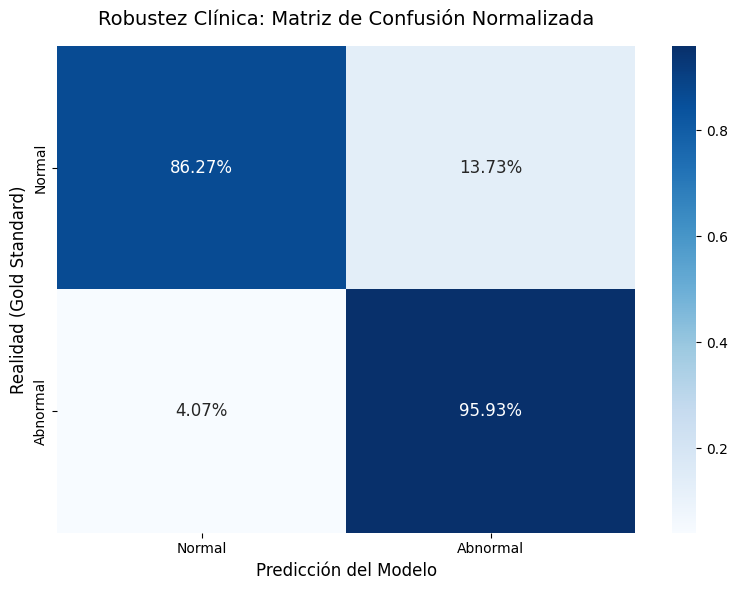


REPORTE DE CLASIFICACIÓN BINARIA (FILTRO AAMI)
              precision    recall  f1-score   support

      Normal     0.9888    0.8627    0.9215     16772
    Abnormal     0.6268    0.9593    0.7582      4031

    accuracy                         0.8815     20803
   macro avg     0.8078    0.9110    0.8399     20803
weighted avg     0.9187    0.8815    0.8898     20803


F1-Score Macro Global: 0.8399


In [110]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import load_model

# ==========================================
# 1. CARGA DEL MODELO (Solución al Custom Object)
# ==========================================
# Para cargar un modelo con pérdida personalizada, pasamos la función generadora 
# directamente en los custom_objects. Asegúrate de usar el nombre de archivo correcto.
print("Cargando modelo entrenado...")
model_path = "../models/classificator_v2_binary_rr_w1500_s40000.keras"

model = load_model(
    model_path,
    custom_objects={'loss': poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=weights_vector)}
)

# ==========================================
# 2. PREDICCIONES
# ==========================================
print("Realizando predicciones sobre el set de test...")
y_pred_raw = model.predict([X_test_sig_norm, X_test_rr_norm])

# Convertimos las salidas Softmax (probabilidades) y One-Hot a etiquetas enteras (0 o 1)
y_pred = np.argmax(y_pred_raw, axis=-1)
y_true = np.argmax(y_test_binary, axis=-1) 

# ==========================================
# 3. MATRIZ DE CONFUSIÓN NORMALIZADA
# ==========================================
# Normalizar por fila ('true') muestra el porcentaje de acierto real sobre el total de cada clase
cm = confusion_matrix(y_true, y_pred, normalize='true')
classes = ['Normal', 'Abnormal']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2%', # Muestra los valores como porcentajes (ej: 98.45%)
    cmap='Blues', 
    xticklabels=classes, 
    yticklabels=classes,
    annot_kws={"size": 12} # Tamaño de la fuente del porcentaje
)
plt.title('Robustez Clínica: Matriz de Confusión Normalizada', fontsize=14, pad=15)
plt.ylabel('Realidad (Gold Standard)', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORTE DE CLASIFICACIÓN CLÍNICA
# ==========================================
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN BINARIA (FILTRO AAMI)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# 5. Métrica Estrella: F1-Score Macro
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"\nF1-Score Macro Global: {macro_f1:.4f}")

In [111]:
# En lugar de y_pred = np.argmax(y_pred_raw, axis=-1)
# y_pred_raw tiene forma (muestras, 2) -> [prob_Normal, prob_Abnormal]

prob_anomala = y_pred_raw[:, 1]
umbral_lista = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# Subimos el listón: solo es Abnormal si el modelo está más del 75% seguro
for umbral in umbral_lista:
    y_pred_calibrado = (prob_anomala > umbral).astype(int)

    # Evalúa ahora con este nuevo y_pred_calibrado
    from sklearn.metrics import classification_report
    print(f"Para {umbral}, los resultados son: \n{classification_report(np.argmax(y_test_binary, axis=-1), y_pred_calibrado, target_names=['Normal', 'Abnormal'])}\n\n")

Para 0.6, los resultados son: 
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95     16772
    Abnormal       0.73      0.93      0.82      4031

    accuracy                           0.92     20803
   macro avg       0.86      0.92      0.88     20803
weighted avg       0.93      0.92      0.92     20803



Para 0.65, los resultados son: 
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96     16772
    Abnormal       0.79      0.90      0.84      4031

    accuracy                           0.93     20803
   macro avg       0.88      0.92      0.90     20803
weighted avg       0.94      0.93      0.94     20803



Para 0.7, los resultados son: 
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96     16772
    Abnormal       0.85      0.85      0.85      4031

    accuracy                           0.94     20803
   macro avg       0.91      0